# Lab 8 — Visualization of Text Data
<hr style="border: 2px solid black;">
Text visualization with **WordCloud**, **TextBlob** and **spaCy / displaCy**.
<hr style="border: 2px solid black;">

In [4]:
# Install required packages (run once)
!pip install -q wordcloud textblob pillow
!python -m spacy download en_core_web_sm -q
!python -m textblob.download_corpora


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 85.4 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
[nltk_data] Downloading package brown to /root/nltk_data...
[nltk_data]   Package brown is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package conll2000 

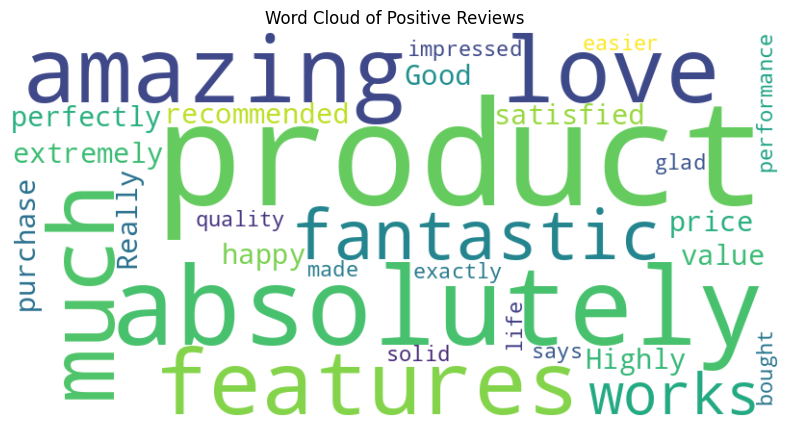

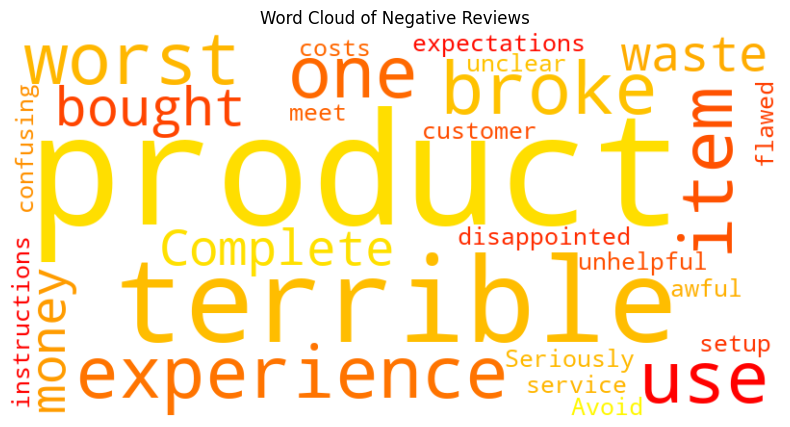

In [5]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from textblob import TextBlob

# Sample reviews with associated sentiment
reviews_with_sentiment = [
    ("This product is absolutely amazing! I love it so much.", "positive"),
    ("The features are fantastic and it works perfectly.", "positive"),
    ("I am extremely happy with this purchase. Highly recommended!", "positive"),
    ("What a terrible experience. The product broke after just one use.", "negative"),
    ("This is the worst item I have ever bought. Complete waste of money.", "negative"),
    ("I was so disappointed. It didn't meet my expectations at all.", "negative"),
    ("It's okay, but nothing special. Could be better.", "neutral"),
    ("Good value for the price. I'm satisfied.", "positive"),
    ("The customer service was awful and unhelpful.", "negative"),
    ("Really impressed with the quality and performance!", "positive"),
    ("Meh, it's alright. Not great, not bad.", "neutral"),
    ("Avoid this product at all costs! Seriously flawed.", "negative"),
    ("So glad I bought this! It has made my life easier.", "positive"),
    ("The setup was confusing and the instructions were unclear.", "negative"),
    ("A solid product that does exactly what it says.", "positive"),
]

# Separate positive and negative reviews
positive_reviews = [review for review, sentiment in reviews_with_sentiment if sentiment == "positive"]
negative_reviews = [review for review, sentiment in reviews_with_sentiment if sentiment == "negative"]

positive_text = " ".join(positive_reviews)
negative_text = " ".join(negative_reviews)

stopwords = set(STOPWORDS)

# --- Word Cloud: Positive Reviews ---
positive_wordcloud = WordCloud(
    width=800, height=400,
    background_color='white',
    stopwords=stopwords,
    min_font_size=10
).generate(positive_text)

plt.figure(figsize=(10, 5))
plt.imshow(positive_wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud of Positive Reviews")
plt.show()

# --- Word Cloud: Negative Reviews ---
negative_wordcloud = WordCloud(
    width=800, height=400,
    background_color='white',
    stopwords=stopwords,
    colormap='autumn',
    min_font_size=10
).generate(negative_text)

plt.figure(figsize=(10, 5))
plt.imshow(negative_wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud of Negative Reviews")
plt.show()


## Named Entity Recognition with spaCy
We use `displacy` to visualize named entities (persons, organizations, locations, money…)
directly inside the notebook.

In [6]:
import spacy
from spacy import displacy

nlp  = spacy.load("en_core_web_sm")
text = "Apple is looking at buying U.K. startup for $1 billion."
doc  = nlp(text)

# Render named entities inline in Jupyter / Colab
displacy.render(doc, style="ent", jupyter=True)
